<a href="https://colab.research.google.com/github/kev841/test-1/blob/main/notebook/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Relevant Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Load Data

In [8]:
data = pd.read_csv('/content/diabetes.csv')
data.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [9]:
data.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
data.nsmallest(5, 'Glucose')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


check for missing data


In [12]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


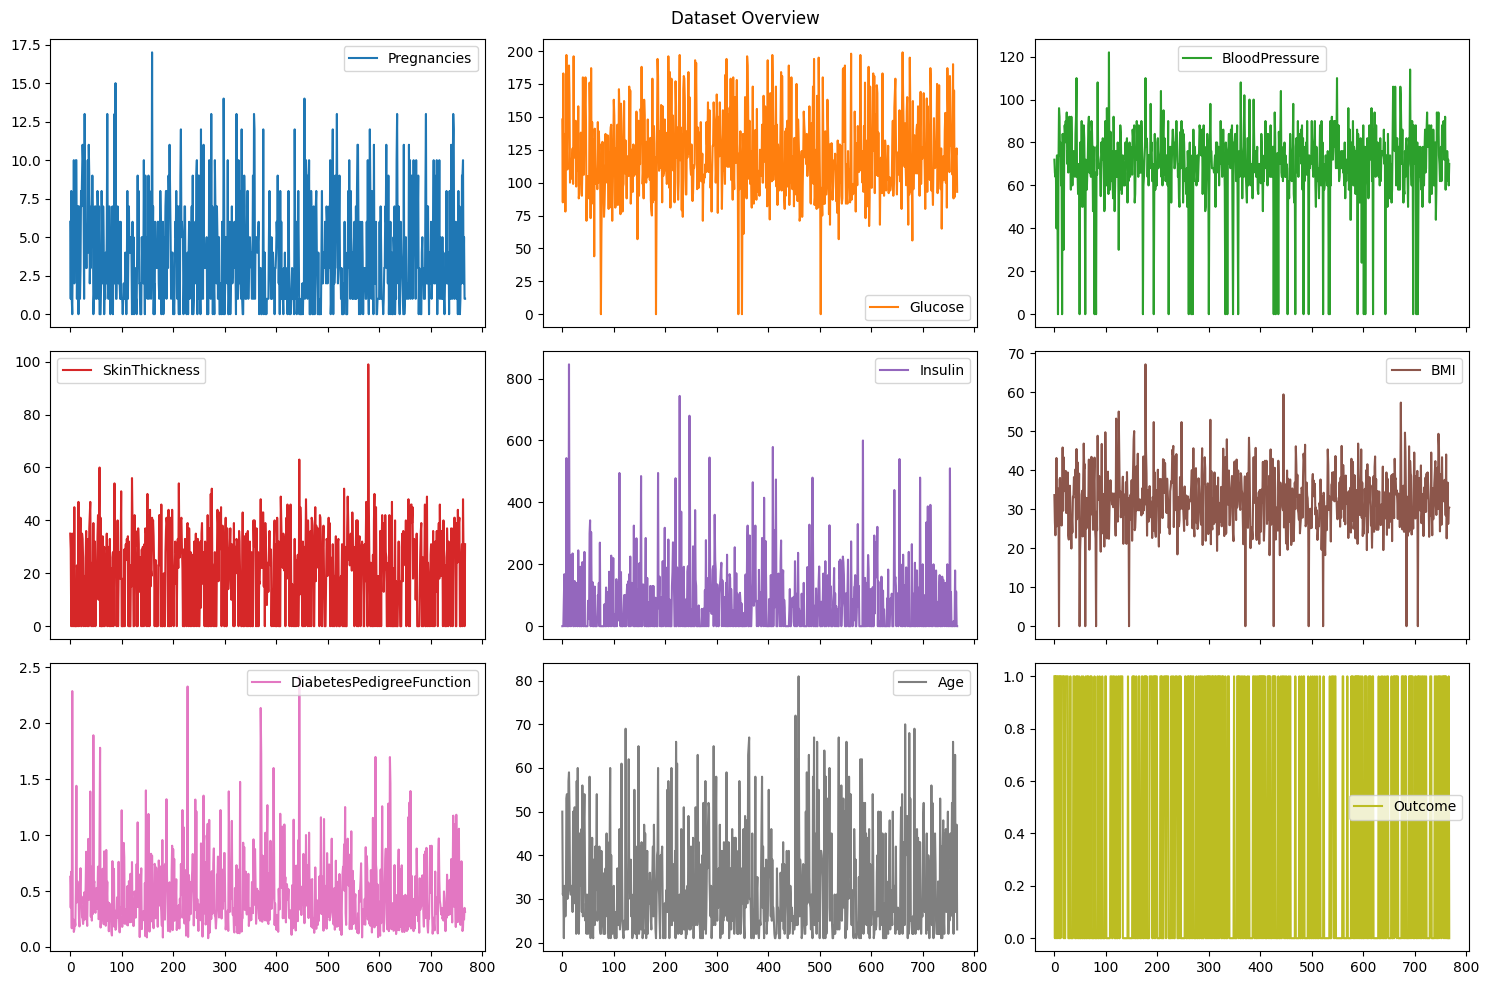

In [13]:
# Plots every column in its own separate graph
data.plot(subplots=True, layout=(3, 3), figsize=(15, 10), title="Dataset Overview")
plt.tight_layout()
plt.show()


In the dataset there are multiple records of zero entries which need to be handled

In [16]:
zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for c in zero_cols:
  print(c, "zero count:", (data[c]==0).sum())

Glucose zero count: 5
BloodPressure zero count: 35
SkinThickness zero count: 227
Insulin zero count: 374
BMI zero count: 11


hanndilng zeros glucose column

In [17]:
# 1. Replace 0 with NaN so they aren't included in median calculation
data['Glucose'] = data['Glucose'].replace(0, np.nan)

# 2/ Fill NaN values with the median of their respective 'Outcome' group
data['Glucose'] = data['Glucose'].fillna(data.groupby('Outcome')['Glucose'].transform('median'))

# 3. Verify there are no zeros or NaNs left
print("Remaining Zeros:", (data['Glucose'] == 0).sum())
print("Remaining NaNs:", data['Glucose'].isnull().sum())

Remaining Zeros: 0
Remaining NaNs: 0
